#Libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report,f1_score

In [ ]:
df = pd.read_csv('/content/Child_Mind_Screen_Time_Dataset_10k.csv')
df.head(20)

,Child_ID,Age,Daily_Screen_Time_Hours,Preferred_Activity,Device_Dependency_Score,Emotional_Response_To_No_Device,Parental_Control_Strictness,Impact_on_Academics,Impact_on_Sleep,Physical_Activity_Level,Social_Interactions_Preference,Parent_Screen_Time_Habits,Sibling_Influence,Cognitive_Impact,Emotional_Regulation_Use,Parental_Monitoring_Level,Gender,Teacher_Feedback,Participation_in_Extracurricular_Activities,Parental_Involvement_in_Education,Peer_Relationship_Quality,Stress_Levels,Favorite_Subject,Hours_of_Sleep
0,Child_1000,6.9,3.8,YouTube Kids,4.9,Neutral,3.9,Negative,Improved,High,Offline,Moderate,Positive,Neutral,NaN,High,Male,Student is maintaining a satisfactory performa...,Low,NaN,Average,Low,Art,6.9
1,Child_1001,9.0,2.5,Gaming,1.9,Distressed,3.9,Negative,Improved,High,NaN,NaN,Negative,Improved,Occasional,NaN,NaN,Student is maintaining a satisfactory performa...,High,Moderate,Good,Moderate,Literature,6.9
2,Child_1002,12.3,4.2,Gaming,9.3,Unbothered,1.8,Neutral,Disrupted,Moderate,Balanced,High,Positive,Neutral,Frequent,Low,NaN,Student's high screen time is impacting classr...,Moderate,Moderate,Poor,Low,Math,7.8
3,Child_1003,11.0,6.1,Gaming,3.9,Neutral,5.1,Neutral,Neutral,High,NaN,Moderate,Negative,NaN,NaN,High,Female,Student's high screen time is impacting classr...,NaN,Low,Good,Low,Math,5.5
4,Child_1004,4.1,3.6,YouTube Kids,2.5,Distressed,NaN,Negative,Disrupted,High,Offline,Low,Neutral,Improved,Frequent,Low,NaN,Student is maintaining a satisfactory performa...,Low,NaN,Poor,Moderate,Math,8.5
5,Child_1005,11.0,3.1,Gaming,6.1,Neutral,2.1,Positive,Neutral,Moderate,Online,Low,Positive,Neutral,Frequent,Low,Female,Student is maintaining a satisfactory performa...,High,Moderate,Average,High,Science,7.9
6,Child_1006,3.2,4.0,Gaming,17.2,Distressed,4.0,Neutral,Neutral,NaN,Balanced,Low,Negative,NaN,Rare,Low,Female,Student is maintaining a satisfactory performa...,Moderate,NaN,Average,Low,Math,7.8
7,Child_1007,7.1,3.7,YouTube Kids,2.2,Irritable,5.4,Neutral,Neutral,High,Offline,Low,Negative,Neutral,Frequent,Low,Female,Student is maintaining a satisfactory performa...,Moderate,Low,Average,Moderate,Literature,8.9
8,Child_1008,12.1,NaN,Video-Watching,7.8,Unbothered,2.1,moderate,Improved,High,balance,Low,Positive,Declined,Frequent,Moderate,NaN,No feedback provided due to missing data.,Low,NaN,Good,Low,Math,9.2
9,Child_1009,NaN,10.5,Edu Apps,2.8,Irritable,5.1,moderate,Improved,positiv,balance,Moderate,Positive,Declined,Rare,Moderate,femaale,Student's high screen time is impacting classr...,NaN,NaN,Excellent,Moderate,Science,5.2


In [ ]:
df.shape

(10000, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Child_ID                                     10000 non-null  object 
 1   Age                                          8513 non-null   float64
 2   Daily_Screen_Time_Hours                      8684 non-null   float64
 3   Preferred_Activity                           8990 non-null   object 
 4   Device_Dependency_Score                      8622 non-null   float64
 5   Emotional_Response_To_No_Device              8455 non-null   object 
 6   Parental_Control_Strictness                  8708 non-null   float64
 7   Impact_on_Academics                          8954 non-null   object 
 8   Impact_on_Sleep                              8528 non-null   object 
 9   Physical_Activity_Level                      8991 non-null   object 
 10 

In [ ]:
df.describe()

,Age,Daily_Screen_Time_Hours,Device_Dependency_Score,Parental_Control_Strictness,Hours_of_Sleep
count,8513.000000,8684.000000,8622.000000,8708.000000,10000.000000
mean,7.491108,5.404537,6.645442,4.212046,7.516950
std,3.356597,5.145885,4.288328,3.174902,1.454073
min,0.000000,0.000000,0.400000,0.400000,4.900000
25%,5.000000,2.100000,3.200000,2.000000,6.200000
50%,7.300000,3.800000,6.100000,3.700000,7.500000
75%,10.000000,5.500000,9.000000,5.000000,8.800000
max,100.200000,24.200000,20.600000,15.400000,10.200000


#Basic Cleaning

In [ ]:
df.drop(columns=['Child_ID'], axis=1, inplace=True)

In [ ]:
df.shape

(10000, 23)

In [ ]:
df.duplicated().sum()

np.int64(22)

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False))


 Preferred_Activity
Preferred_Activity
Video Watching      1544
Gaming              1487
YouTube Kids        1475
Educational Apps    1438
NaN                 1009
Video-Watching       814
YouTubeKid           809
Edu Apps             761
Gamee                641
Name: count, dtype: int64

 Emotional_Response_To_No_Device
Emotional_Response_To_No_Device
Distressed    2194
Irritable     2122
Neutral       2070
Unbothered    2050
NaN           1542
Name: count, dtype: int64

 Impact_on_Academics
Impact_on_Academics
Negative    2388
Positive    2305
Neutral     2230
NaN         1045
Low         1007
High         532
moderate     471
Name: count, dtype: int64

 Impact_on_Sleep
Impact_on_Sleep
Improved     2919
Neutral      2896
Disrupted    2694
NaN          1469
Name: count, dtype: int64

 Physical_Activity_Level
Physical_Activity_Level
High         2776
Low          2324
Moderate     1824
NaN          1008
negativee     571
positiv       531
LOW           527
moderate      417
Name: cou

In [ ]:
df['Preferred_Activity'] = df['Preferred_Activity'].replace({
    'Video-Watching': 'Video Watching',
    'YouTubeKid': 'YouTube Kids',
    'Edu Apps': 'Educational Apps',
    'Gamee': 'Gaming'
})

In [ ]:
print(df['Preferred_Activity'].value_counts(dropna=False))

Preferred_Activity
Video Watching      2358
YouTube Kids        2284
Educational Apps    2199
Gaming              2128
NaN                 1009
Name: count, dtype: int64


In [ ]:
df['Impact_on_Academics'] = df['Impact_on_Academics'].replace({
    'Low': 'Negative',
    'moderate': 'Neutral',
    'High': 'Positive'
})

In [ ]:
print(df['Impact_on_Academics'].value_counts(dropna=False))

Impact_on_Academics
Negative    3395
Positive    2837
Neutral     2701
NaN         1045
Name: count, dtype: int64


In [ ]:
df['Physical_Activity_Level'] = df['Physical_Activity_Level'].replace({
    'HIGH': 'High',
    'LOW': 'Low',
    'loww': 'Low',
    'moderate': 'Moderate',
    'negativee': 'Low',
    'positiv': 'High'
})

In [ ]:
print(df['Physical_Activity_Level'].value_counts(dropna=False))

Physical_Activity_Level
Low         3422
High        3307
Moderate    2241
NaN         1008
Name: count, dtype: int64


In [ ]:
df['Social_Interactions_Preference'] = df['Social_Interactions_Preference'].replace({
    'balance': 'Balanced',
    'Offliine': 'Offline',
    'onliine': 'Online'
})

In [ ]:
print(df['Social_Interactions_Preference'].value_counts(dropna=False))

Social_Interactions_Preference
Balanced    2756
Offline     2726
Online      2634
NaN         1862
Name: count, dtype: int64


In [ ]:
df['Gender'] = df['Gender'].replace({
    'malee': 'Male',
    'femaale': 'Female',
    'F': 'Female'
})

In [ ]:
print(df['Gender'].value_counts(dropna=False))

Gender
Male       3713
Female     3528
NaN        2028
unknown     709
Name: count, dtype: int64


In [ ]:
df['Teacher_Feedback'].value_counts()

,count
Teacher_Feedback,
Student's high screen time is impacting classroom performance and limiting creative expression. Reducing screen time could significantly enhance their focus and originality.,3827
Student is maintaining a satisfactory performance in class but shows room for improvement in creativity. Moderate screen time could be better managed to encourage more creative thinking.,2476
Student is performing well in class and demonstrates excellent creativity. The balanced screen time seems to contribute positively to their engagement and imagination.,1872
No feedback provided due to missing data.,1210
isufigifgb fiuewhfwef,8


In [ ]:
df['Teacher_Feedback'] = df['Teacher_Feedback'].replace({
    "Student's high screen time is impacting classroom performance and limiting creative expression. Reducing screen time could significantly enhance their focus and originality.": 'Negative',
    "No feedback provided due to missing data.": 'No feedback',
    "Student is maintaining a satisfactory performance in class but shows room for improvement in creativity. Moderate screen time could be better managed to encourage more creative thinking.":'Moderate',
    "Student is performing well in class and demonstrates excellent creativity. The balanced screen time seems to contribute positively to their engagement and imagination.":'Positive',
    "isufigifgb  fiuewhfwef":'No feedback'
})

In [ ]:
print(df['Teacher_Feedback'].value_counts(dropna=False))

Teacher_Feedback
Negative       3827
Moderate       2476
Positive       1872
No feedback    1218
NaN             585
Name: count, dtype: int64


#EDA

In [ ]:
df.isna().sum()

,0
Age,1479
Daily_Screen_Time_Hours,1306
Preferred_Activity,1009
Device_Dependency_Score,1369
Emotional_Response_To_No_Device,1542
Parental_Control_Strictness,1285
Impact_on_Academics,1045
Impact_on_Sleep,1469
Physical_Activity_Level,1008
Social_Interactions_Preference,1862


In [ ]:
print(df['Stress_Levels'].value_counts())

Stress_Levels
Moderate    3382
High        3335
Low         3261
Name: count, dtype: int64


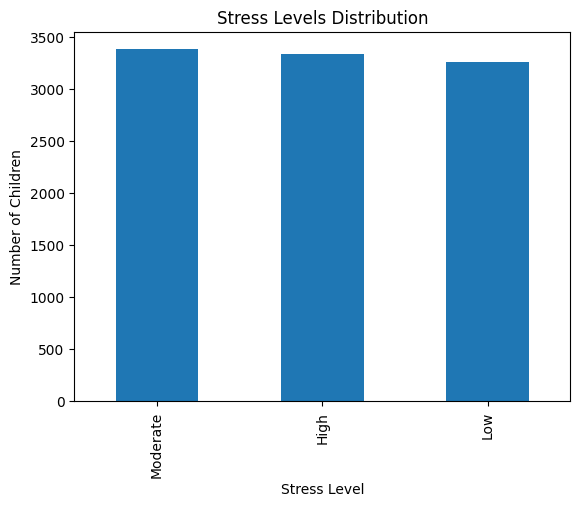

In [ ]:
df['Stress_Levels'].value_counts().plot(kind='bar')

plt.title('Stress Levels Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Number of Children')
plt.show()

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

print(numeric_cols)

Index(['Age', 'Daily_Screen_Time_Hours', 'Device_Dependency_Score',
       'Parental_Control_Strictness', 'Hours_of_Sleep'],
      dtype='object')


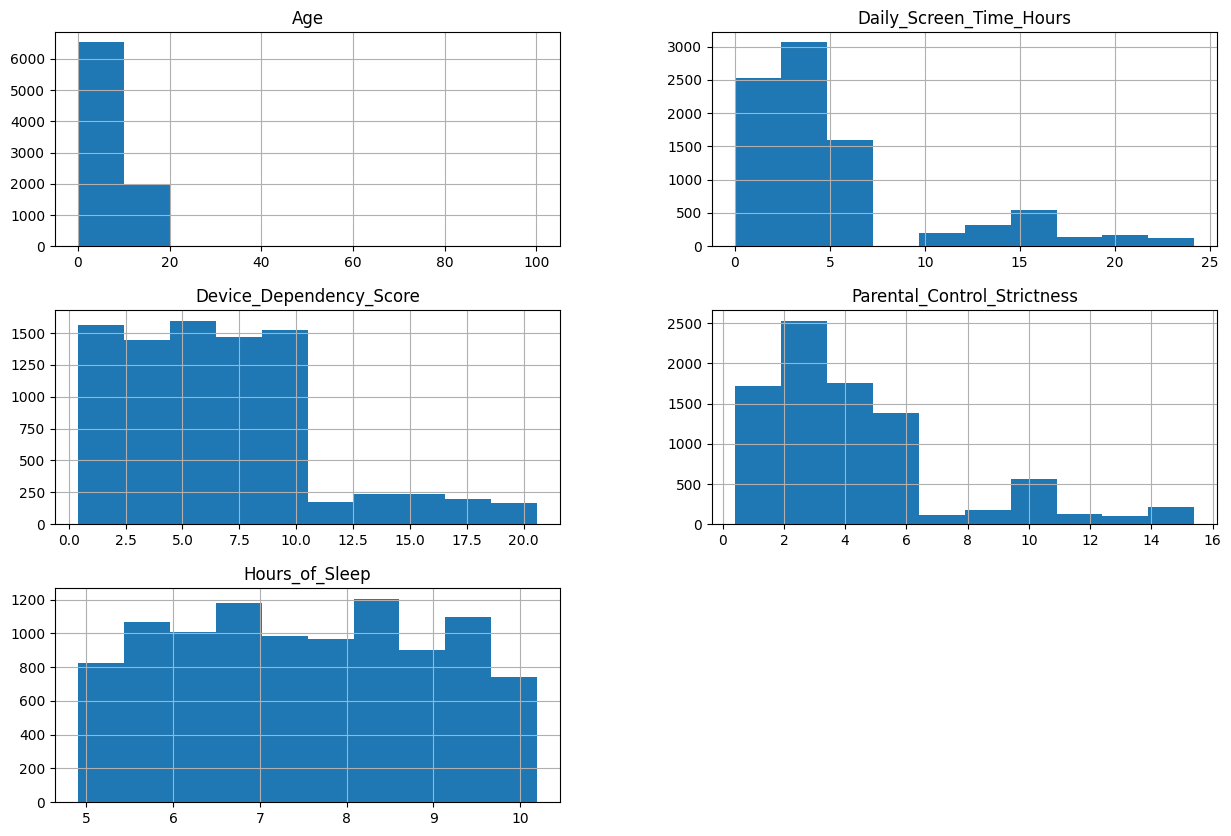

In [ ]:
df[numeric_cols].hist(figsize=(15,10))
plt.show()

In [ ]:
df.describe()

,Age,Daily_Screen_Time_Hours,Device_Dependency_Score,Parental_Control_Strictness,Hours_of_Sleep
count,8499.000000,8672.000000,8609.000000,8693.000000,9978.000000
mean,7.490234,5.404151,6.646184,4.213770,7.516637
std,3.356859,5.144265,4.288327,3.176131,1.454592
min,0.000000,0.000000,0.400000,0.400000,4.900000
25%,5.000000,2.100000,3.200000,2.000000,6.200000
50%,7.300000,3.800000,6.100000,3.700000,7.500000
75%,10.000000,5.500000,9.000000,5.000000,8.800000
max,100.200000,24.200000,20.600000,15.400000,10.200000


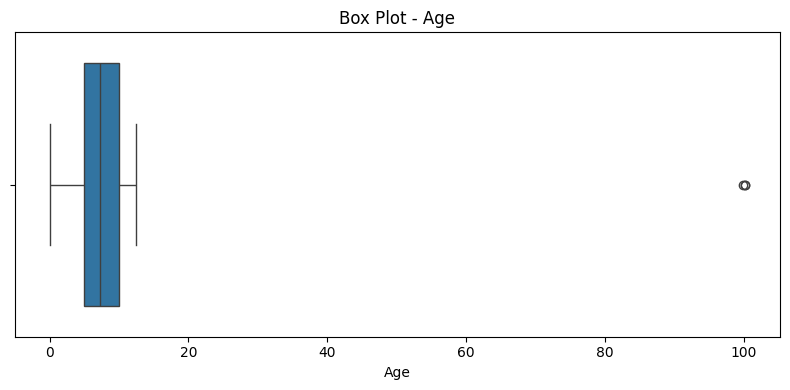

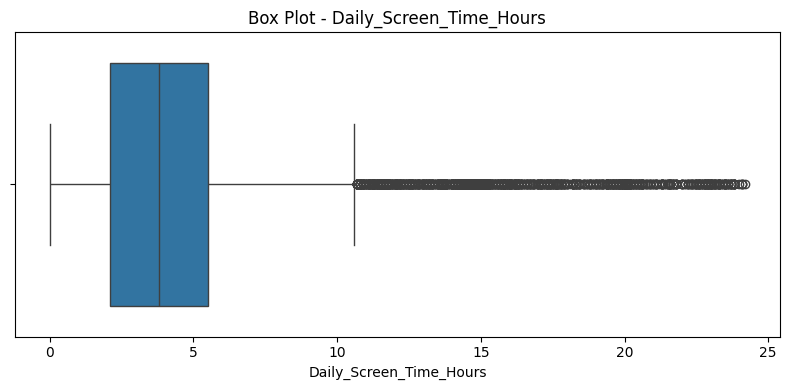

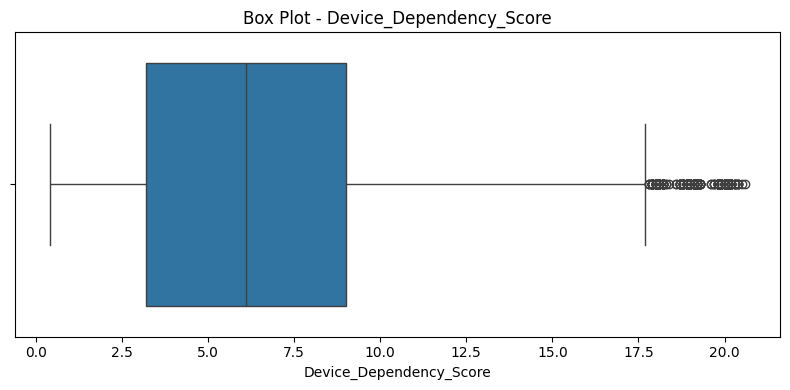

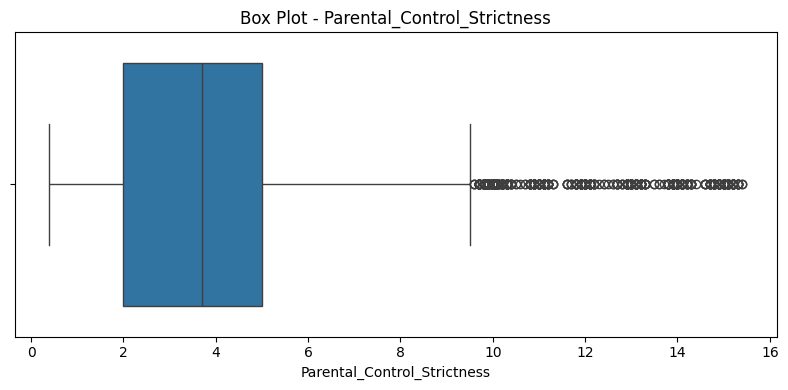

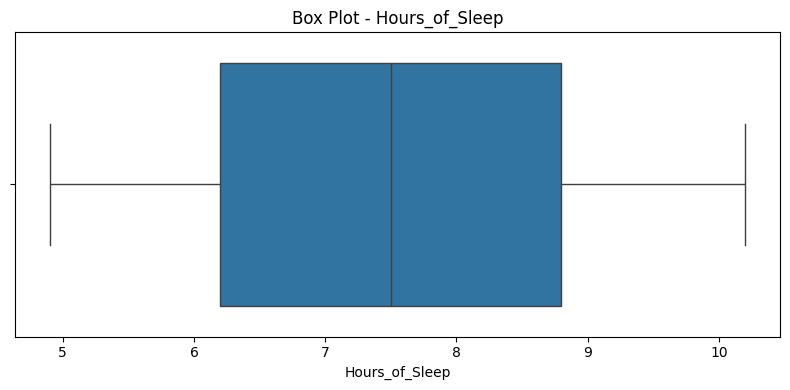

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Box Plot - {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
df['Age'].value_counts()

,count
Age,
3.0,228
4.0,226
9.0,217
6.0,216
10.0,203
...,...
12.5,4
100.2,2
10.5,2


In [ ]:
df.loc[(df['Age'] < 2) | (df['Age'] > 13), 'Age'] = np.nan

In [ ]:
df['Age'].value_counts()

,count
Age,
3.0,228
4.0,226
9.0,217
6.0,216
10.0,203
...,...
11.5,5
9.5,4
12.5,4


In [ ]:
df['Daily_Screen_Time_Hours'].value_counts()

,count
Daily_Screen_Time_Hours,
5.3,162
1.3,156
5.4,155
5.2,154
2.5,153
...,...
21.2,1
24.2,1
6.7,1


In [ ]:
df.loc[df['Daily_Screen_Time_Hours'] > 24, 'Daily_Screen_Time_Hours'] = np.nan

In [ ]:
df['Daily_Screen_Time_Hours'].value_counts()

,count
Daily_Screen_Time_Hours,
5.3,162
1.3,156
5.4,155
5.2,154
2.5,153
...,...
24.0,1
21.2,1
6.7,1


In [ ]:
df['Device_Dependency_Score'].value_counts()

,count
Device_Dependency_Score,
5.0,163
2.0,160
9.0,154
1.0,150
5.9,147
...,...
18.6,2
18.4,1
20.5,1


In [ ]:
df.loc[df['Device_Dependency_Score'] > 10, 'Device_Dependency_Score'] = np.nan

In [ ]:
df['Device_Dependency_Score'].value_counts()

,count
Device_Dependency_Score,
5.0,163
2.0,160
9.0,154
1.0,150
5.9,147
...,...
3.5,13
6.5,12
4.5,11


In [ ]:
df['Parental_Control_Strictness'].value_counts()

,count
Parental_Control_Strictness,
2.0,395
1.0,380
4.0,367
5.0,363
4.9,335
...,...
14.4,1
7.6,1
5.6,1


In [ ]:
df.loc[df['Parental_Control_Strictness'] > 10, 'Parental_Control_Strictness'] = np.nan

In [ ]:
df['Parental_Control_Strictness'].value_counts()

,count
Parental_Control_Strictness,
2.0,395
1.0,380
4.0,367
5.0,363
4.9,335
...,...
0.4,1
7.6,1
5.6,1


In [ ]:
print(df.isnull().sum().sort_values(ascending=False))

Device_Dependency_Score                        2660
Parental_Involvement_in_Education              2493
Participation_in_Extracurricular_Activities    2408
Gender                                         2028
Parental_Control_Strictness                    1959
Social_Interactions_Preference                 1862
Cognitive_Impact                               1550
Emotional_Response_To_No_Device                1542
Emotional_Regulation_Use                       1521
Sibling_Influence                              1502
Age                                            1486
Impact_on_Sleep                                1469
Parental_Monitoring_Level                      1467
Parent_Screen_Time_Habits                      1465
Daily_Screen_Time_Hours                        1310
Impact_on_Academics                            1045
Preferred_Activity                             1009
Physical_Activity_Level                        1008
Teacher_Feedback                                585
Favorite_Sub

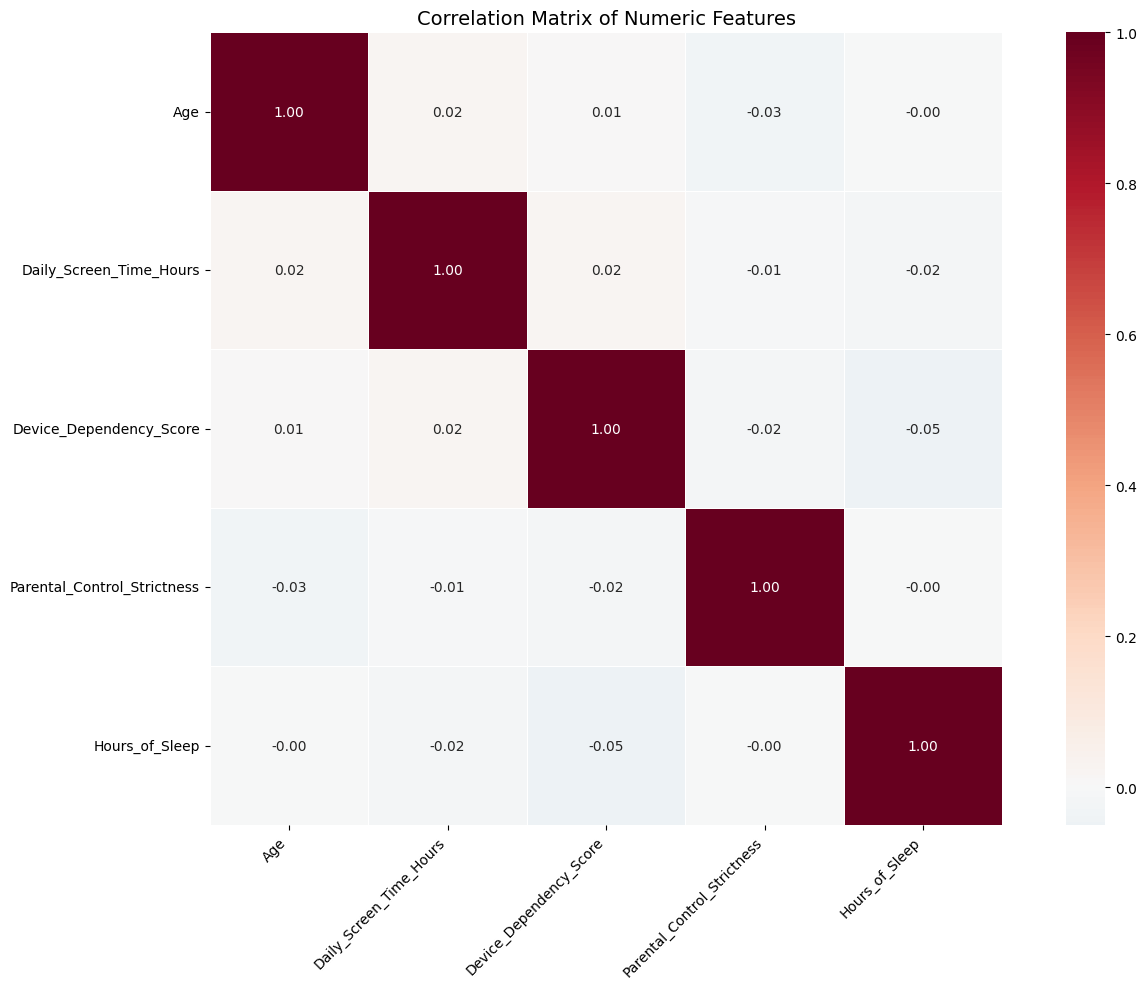

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix of Numeric Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

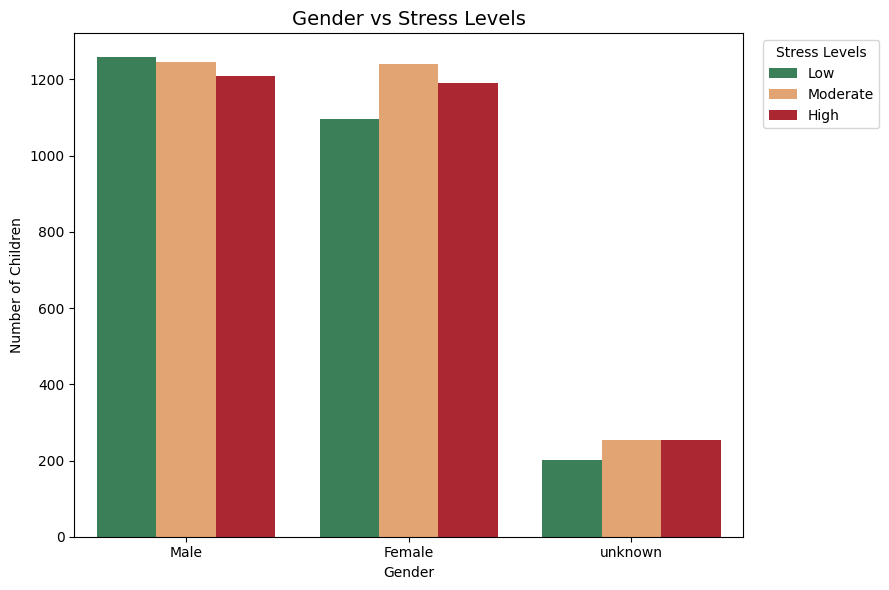

In [ ]:
stress_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

plt.figure(figsize=(9, 6))

sns.countplot(
    x='Gender',
    hue='Stress_Levels',
    data=df,
    hue_order=['Low', 'Moderate', 'High'],
    palette=stress_colors
)

plt.title('Gender vs Stress Levels', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Number of Children')

plt.legend(
    title='Stress Levels',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

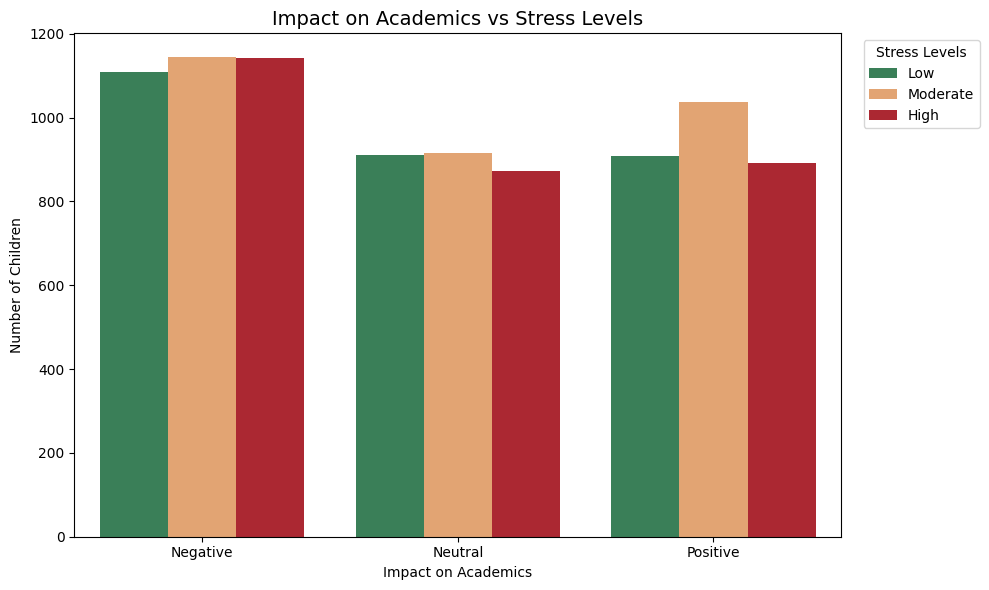

In [ ]:
stress_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

plt.figure(figsize=(10, 6))

sns.countplot(
    x='Impact_on_Academics',
    hue='Stress_Levels',
    data=df,
    hue_order=['Low', 'Moderate', 'High'],
    palette=stress_colors
)

plt.title('Impact on Academics vs Stress Levels', fontsize=14)
plt.xlabel('Impact on Academics')
plt.ylabel('Number of Children')

plt.legend(
    title='Stress Levels',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

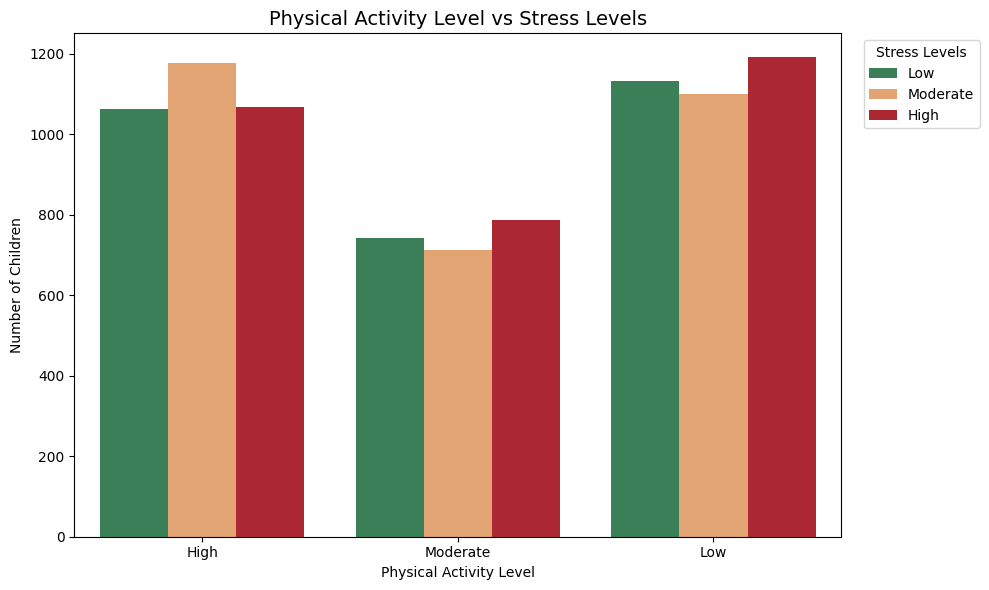

In [ ]:
stress_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

plt.figure(figsize=(10, 6))

sns.countplot(
    x='Physical_Activity_Level',
    hue='Stress_Levels',
    data=df,
    hue_order=['Low', 'Moderate', 'High'],
    palette=stress_colors
)

plt.title('Physical Activity Level vs Stress Levels', fontsize=14)
plt.xlabel('Physical Activity Level')
plt.ylabel('Number of Children')

plt.legend(
    title='Stress Levels',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

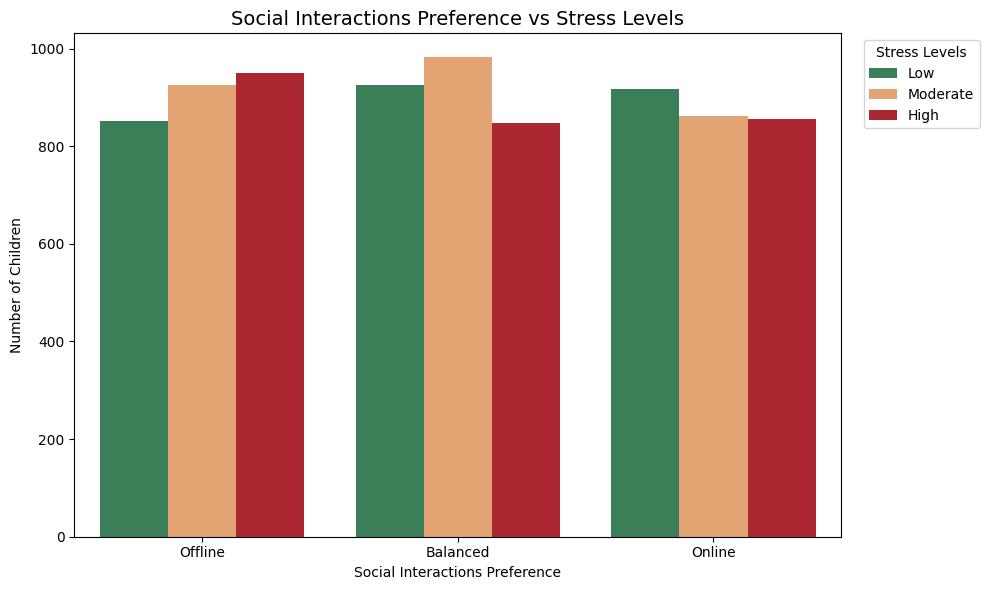

In [ ]:
stress_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

plt.figure(figsize=(10, 6))

sns.countplot(
    x='Social_Interactions_Preference',
    hue='Stress_Levels',
    data=df,
    hue_order=['Low', 'Moderate', 'High'],
    palette=stress_colors
)

plt.title('Social Interactions Preference vs Stress Levels', fontsize=14)
plt.xlabel('Social Interactions Preference')
plt.ylabel('Number of Children')

plt.legend(
    title='Stress Levels',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

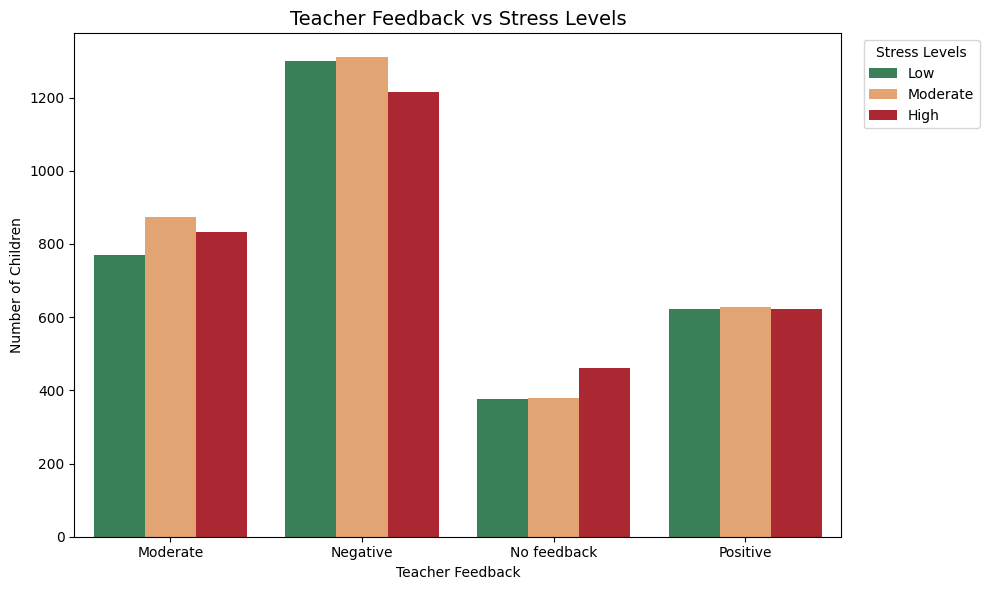

In [ ]:
stress_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

plt.figure(figsize=(10, 6))

sns.countplot(
    x='Teacher_Feedback',
    hue='Stress_Levels',
    data=df,
    hue_order=['Low', 'Moderate', 'High'],
    palette=stress_colors
)

plt.title('Teacher Feedback vs Stress Levels', fontsize=14)
plt.xlabel('Teacher Feedback')
plt.ylabel('Number of Children')

plt.legend(
    title='Stress Levels',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

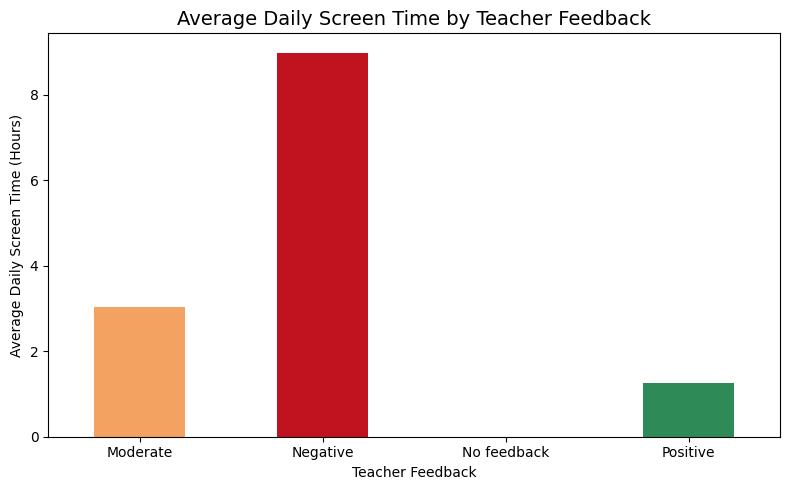

In [ ]:
mean_screen_time = df.groupby(
    'Teacher_Feedback'
)['Daily_Screen_Time_Hours'].mean()

feedback_colors = {
    'Positive': '#2E8B57',
    'Moderate': '#F4A261',
    'Negative': '#C1121F',
    'No feedback': '#A8A8A8'
}

mean_screen_time.plot(
    kind='bar',
    figsize=(8, 5),
    color=[feedback_colors[x] for x in mean_screen_time.index]
)

plt.title('Average Daily Screen Time by Teacher Feedback', fontsize=14)
plt.xlabel('Teacher Feedback')
plt.ylabel('Average Daily Screen Time (Hours)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

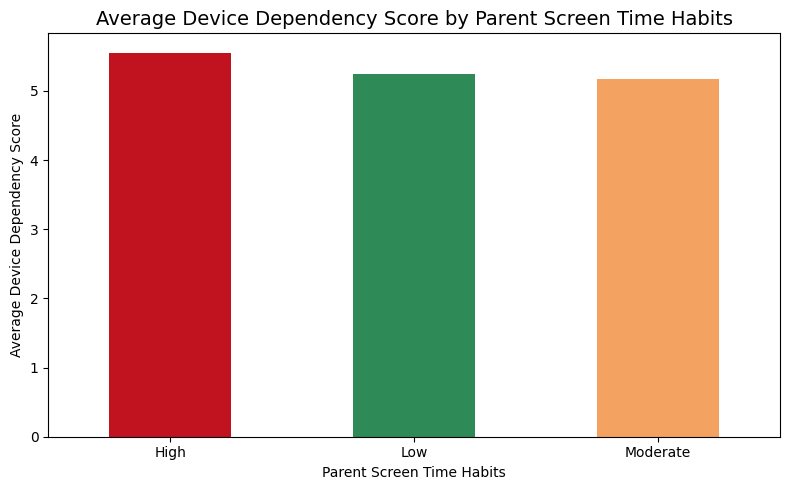

In [ ]:
mean_device = df.groupby(
    'Parent_Screen_Time_Habits'
)['Device_Dependency_Score'].mean()

habit_colors = {
    'Low': '#2E8B57',
    'Moderate': '#F4A261',
    'High': '#C1121F'
}

mean_device.plot(
    kind='bar',
    figsize=(8, 5),
    color=[habit_colors[x] for x in mean_device.index]
)

plt.title(
    'Average Device Dependency Score by Parent Screen Time Habits',
    fontsize=14
)

plt.xlabel('Parent Screen Time Habits')
plt.ylabel('Average Device Dependency Score')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

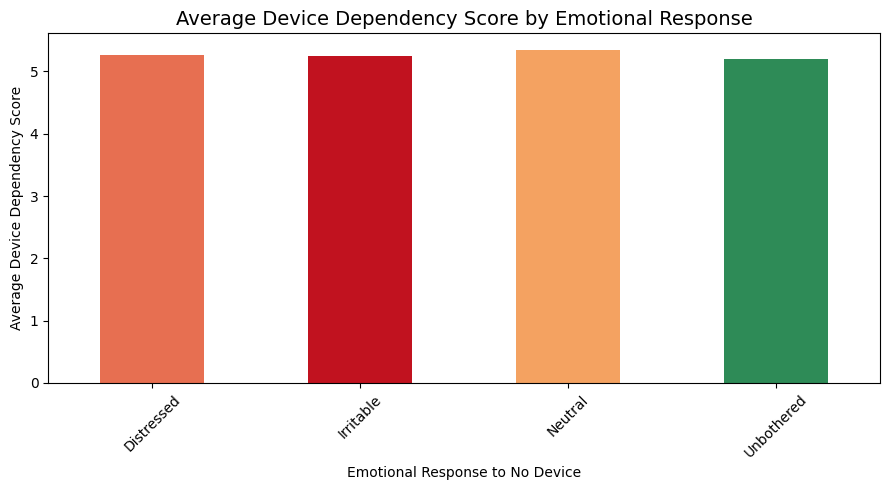

In [ ]:
mean_device = df.groupby(
    'Emotional_Response_To_No_Device'
)['Device_Dependency_Score'].mean()

response_colors = {
    'Distressed': '#E76F51',
    'Irritable': '#C1121F',
    'Neutral': '#F4A261'
}

colors = [
    response_colors.get(x, '#2E8B57')
    for x in mean_device.index
]

mean_device.plot(
    kind='bar',
    figsize=(9, 5),
    color=colors
)

plt.title(
    'Average Device Dependency Score by Emotional Response',
    fontsize=14
)

plt.xlabel('Emotional Response to No Device')
plt.ylabel('Average Device Dependency Score')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

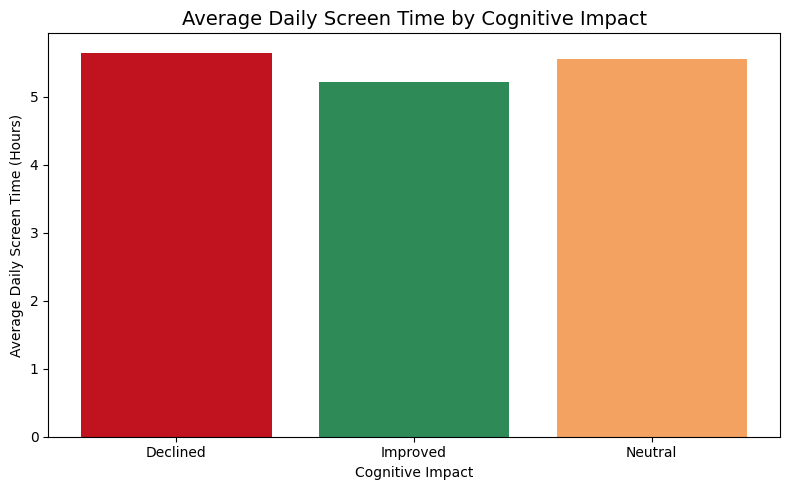

In [ ]:
df['Cognitive_Impact'] = df['Cognitive_Impact'].str.strip()

mean_screen_time = df.groupby(
    'Cognitive_Impact'
)['Daily_Screen_Time_Hours'].mean()

cognitive_colors = {
    'Declined': '#C1121F',
    'Improved': '#2E8B57',
    'Neutral': '#F4A261'
}

colors = [
    cognitive_colors.get(category, '#457B9D')
    for category in mean_screen_time.index
]

plt.figure(figsize=(8, 5))

plt.bar(
    mean_screen_time.index,
    mean_screen_time.values,
    color=colors
)

plt.title(
    'Average Daily Screen Time by Cognitive Impact',
    fontsize=14
)

plt.xlabel('Cognitive Impact')
plt.ylabel('Average Daily Screen Time (Hours)')

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

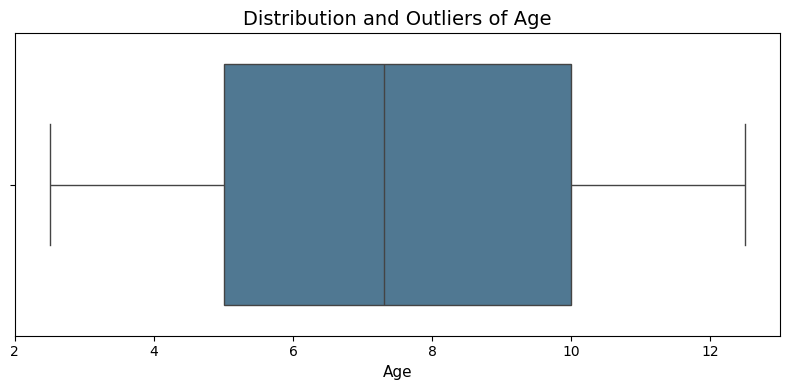

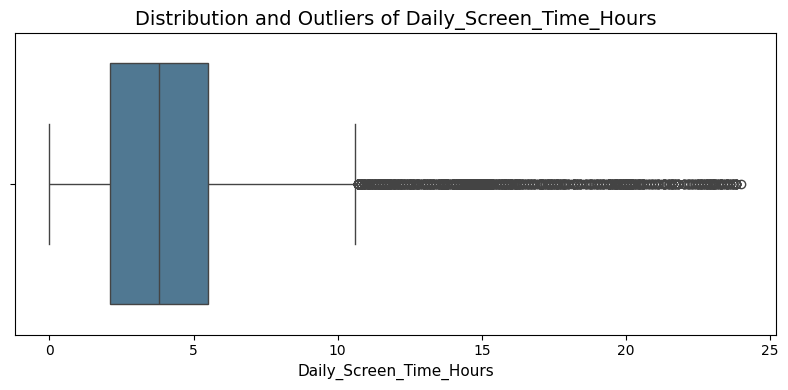

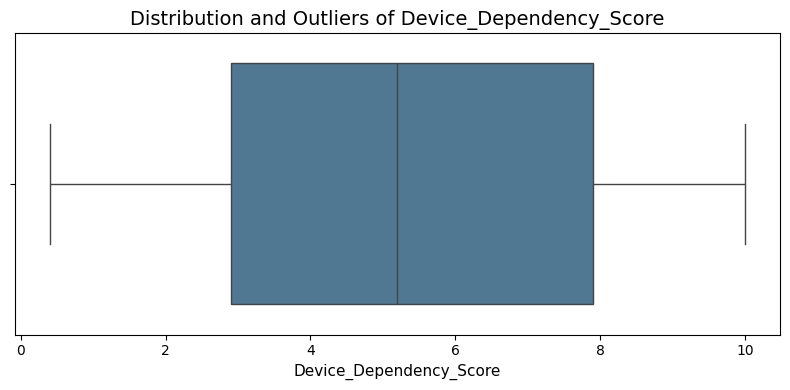

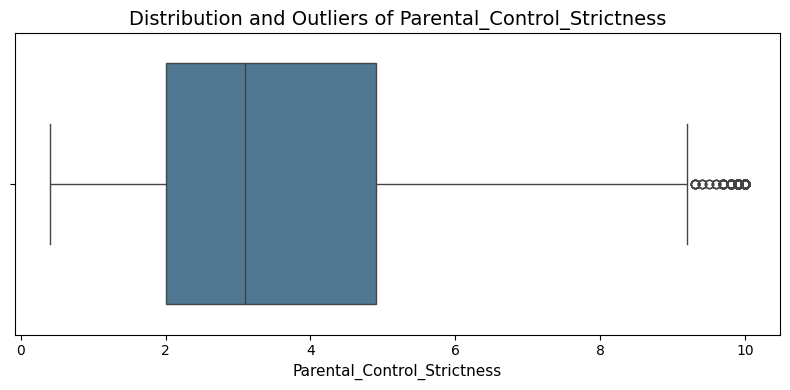

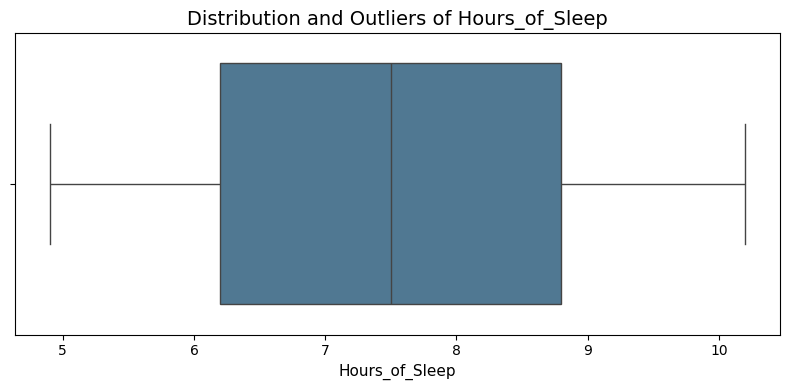

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col],
        color='#457B9D'
    )

    plt.title(f'Distribution and Outliers of {col}', fontsize=14)
    plt.xlabel(col, fontsize=11)

    plt.tight_layout()
    plt.show()

#Preprocessing

In [ ]:
label = LabelEncoder()

df['Stress_Levels'] = label.fit_transform(df['Stress_Levels'])

In [ ]:
print(df['Stress_Levels'].value_counts())
print(label.classes_)

Stress_Levels
2    3382
0    3335
1    3261
Name: count, dtype: int64
['High' 'Low' 'Moderate']


In [ ]:
X = df.drop('Stress_Levels', axis=1)
y = df['Stress_Levels']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7982, 22)
X_test: (1996, 22)
y_train: (7982,)
y_test: (1996,)


#Handle Null Values

In [ ]:
numeric_cols = X_train.select_dtypes(include='number').columns
categorical_cols = X_train.select_dtypes(include='object').columns

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
Index(['Age', 'Daily_Screen_Time_Hours', 'Device_Dependency_Score',
       'Parental_Control_Strictness', 'Hours_of_Sleep'],
      dtype='object')

Categorical columns:
Index(['Preferred_Activity', 'Emotional_Response_To_No_Device',
       'Impact_on_Academics', 'Impact_on_Sleep', 'Physical_Activity_Level',
       'Social_Interactions_Preference', 'Parent_Screen_Time_Habits',
       'Sibling_Influence', 'Cognitive_Impact', 'Emotional_Regulation_Use',
       'Parental_Monitoring_Level', 'Gender', 'Teacher_Feedback',
       'Participation_in_Extracurricular_Activities',
       'Parental_Involvement_in_Education', 'Peer_Relationship_Quality',
       'Favorite_Subject'],
      dtype='object')


In [ ]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

In [ ]:
print("Train missing values:", X_train.isnull().sum().sum())
print("Test missing values:", X_test.isnull().sum().sum())

Train missing values: 0
Test missing values: 0


#Encoding

In [ ]:
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['Age', 'Daily_Screen_Time_Hours', 'Device_Dependency_Score', 'Parental_Control_Strictness', 'Hours_of_Sleep']

Categorical columns:
['Preferred_Activity', 'Emotional_Response_To_No_Device', 'Impact_on_Academics', 'Impact_on_Sleep', 'Physical_Activity_Level', 'Social_Interactions_Preference', 'Parent_Screen_Time_Habits', 'Sibling_Influence', 'Cognitive_Impact', 'Emotional_Regulation_Use', 'Parental_Monitoring_Level', 'Gender', 'Teacher_Feedback', 'Participation_in_Extracurricular_Activities', 'Parental_Involvement_in_Education', 'Peer_Relationship_Quality', 'Favorite_Subject']


In [ ]:
for col in categorical_cols:
    print(f"\n{col}:")
    print(X_train[col].unique())


Preferred_Activity:
['YouTube Kids' 'Video Watching' 'Gaming' 'Educational Apps']

Emotional_Response_To_No_Device:
['Unbothered' 'Neutral' 'Irritable' 'Distressed']

Impact_on_Academics:
['Negative' 'Neutral' 'Positive']

Impact_on_Sleep:
['Neutral' 'Improved' 'Disrupted']

Physical_Activity_Level:
['Low' 'Moderate' 'High']

Social_Interactions_Preference:
['Online' 'Offline' 'Balanced']

Parent_Screen_Time_Habits:
['Low' 'Moderate' 'High']

Sibling_Influence:
['Neutral' 'Negative' 'Positive']

Cognitive_Impact:
['Neutral' 'Declined' 'Improved']

Emotional_Regulation_Use:
['Rare' 'Occasional' 'Frequent']

Parental_Monitoring_Level:
['High' 'Moderate' 'Low']

Gender:
['Female' 'Male' 'unknown']

Teacher_Feedback:
['No feedback' 'Positive' 'Negative' 'Moderate']

Participation_in_Extracurricular_Activities:
['Low' 'Moderate' 'High']

Parental_Involvement_in_Education:
['High' 'Low' 'Moderate']

Peer_Relationship_Quality:
['Good' 'Average' 'Poor' 'Excellent']

Favorite_Subject:
['Math' 

In [ ]:
ordinal_cols = [
    'Impact_on_Academics',
    'Impact_on_Sleep',
    'Physical_Activity_Level',
    'Parent_Screen_Time_Habits',
    'Sibling_Influence',
    'Cognitive_Impact',
    'Emotional_Regulation_Use',
    'Parental_Monitoring_Level',
    'Participation_in_Extracurricular_Activities',
    'Parental_Involvement_in_Education',
    'Peer_Relationship_Quality'
]

nominal_cols = [
    'Preferred_Activity',
    'Emotional_Response_To_No_Device',
    'Social_Interactions_Preference',
    'Gender',
    'Teacher_Feedback',
    'Favorite_Subject'
]

In [ ]:
ordinal_order = [
    ['Negative', 'Neutral', 'Positive'],              # Impact_on_Academics
    ['Disrupted', 'Neutral', 'Improved'],             # Impact_on_Sleep
    ['Low', 'Moderate', 'High'],                      # Physical_Activity_Level
    ['Low', 'Moderate', 'High'],                      # Parent_Screen_Time_Habits
    ['Negative', 'Neutral', 'Positive'],              # Sibling_Influence
    ['Declined', 'Neutral', 'Improved'],              # Cognitive_Impact
    ['Rare', 'Occasional', 'Frequent'],               # Emotional_Regulation_Use
    ['Low', 'Moderate', 'High'],                      # Parental_Monitoring_Level
    ['Low', 'Moderate', 'High'],                      # Participation_in_Extracurricular_Activities
    ['Low', 'Moderate', 'High'],                      # Parental_Involvement_in_Education
    ['Poor', 'Average', 'Good', 'Excellent']          # Peer_Relationship_Quality
]

ordinal_encoder = OrdinalEncoder(
    categories=ordinal_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train_ordinal = ordinal_encoder.fit_transform(
    X_train[ordinal_cols]
)

X_test_ordinal = ordinal_encoder.transform(
    X_test[ordinal_cols]
)

print("X_train_ordinal shape:", X_train_ordinal.shape)
print("X_test_ordinal shape:", X_test_ordinal.shape)

X_train_ordinal shape: (7982, 11)
X_test_ordinal shape: (1996, 11)


In [ ]:
onehot_encoder = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False
)

X_train_nominal = onehot_encoder.fit_transform(
    X_train[nominal_cols]
)

X_test_nominal = onehot_encoder.transform(
    X_test[nominal_cols]
)

print("X_train_nominal shape:", X_train_nominal.shape)
print("X_test_nominal shape:", X_test_nominal.shape)

X_train_nominal shape: (7982, 23)
X_test_nominal shape: (1996, 23)


In [ ]:
X_train_encoded = np.hstack([
    X_train[numeric_cols].values,
    X_train_ordinal,
    X_train_nominal
])

X_test_encoded = np.hstack([
    X_test[numeric_cols].values,
    X_test_ordinal,
    X_test_nominal
])

print("X_train_encoded shape:", X_train_encoded.shape)
print("X_test_encoded shape:", X_test_encoded.shape)

X_train_encoded shape: (7982, 39)
X_test_encoded shape: (1996, 39)


In [ ]:
print("NaN in X_train:", np.isnan(X_train_encoded).sum())
print("NaN in X_test:", np.isnan(X_test_encoded).sum())

NaN in X_train: 0
NaN in X_test: 0


#Feature Selection

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)

X_train_selected = selector.fit_transform(
    X_train_encoded,
    y_train
)

X_test_selected = selector.transform(
    X_test_encoded
)

print("Before Feature Selection:", X_train_encoded.shape)
print("After Feature Selection:", X_train_selected.shape)

Before Feature Selection: (7982, 39)
After Feature Selection: (7982, 15)


In [ ]:
print("X_test_selected shape:", X_test_selected.shape)

X_test_selected shape: (1996, 15)


#Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_selected, y_train)

y_train_pred = rf_model.predict(X_train_selected)
y_test_pred = rf_model.predict(X_test_selected)

In [ ]:
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

print("\nTest F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

Train Accuracy: 1.0
Test Accuracy: 0.8927855711422845

Test F1 Score: 0.8928053562823102

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89       667
           1       0.91      0.89      0.90       652
           2       0.88      0.90      0.89       677

    accuracy                           0.89      1996
   macro avg       0.89      0.89      0.89      1996
weighted avg       0.89      0.89      0.89      1996



#Save Files

In [ ]:
import joblib
joblib.dump(label, 'label_file.joblib') # Save label
joblib.dump(num_imputer, 'num_imputer_file.joblib') # Save num_imputer
joblib.dump(cat_imputer, 'cat_imputer_file.joblib') # Save cat_imputer
joblib.dump(ordinal_encoder, 'ordinal_encoder_file.joblib') # Save ordinal_encoder
joblib.dump(onehot_encoder, 'onehot_encoder_file.joblib') # Save onehot_encoder
joblib.dump(selector, 'selector_file.joblib') # Save selector
joblib.dump(rf_model, 'rf_model_file.joblib') # Save rf_model

['rf_model_file.joblib']